<a href="https://colab.research.google.com/github/ODZ-UJF-AV-CR/SPACEDOS-ISS-RadLab/blob/main/SPACEDOS_ISS_2020_correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPACEDOS02

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, timezone
from IPython.display import Image as ImageDisp
from pandas import DataFrame
import string
import os
import glob
import matplotlib.pyplot as plt
import matplotlib
import gdown
%matplotlib inline

# SPACEDOS ISS 2020-2021

Launch Soyuz MS-17: 14 October 2020, 05:45:04
- Launch site: Baikonur
- Launch pad: Site 31
- Altitude: 420 km
- Inclination: 51,6°

### Docking ISS: 14 October 2020, 08:48:47 UTC
### Undocking ISS: 17 April 2021, 01:34 UTC
Landing Soyuz MS-17: 17 April 2021, 04:55 UTC
- Landing site: Kazakh Steppe

_Note: Gaps in measurement after measurement number 678000_

## Flux and Doserate

In [2]:
# Copy data from iss2019.csv to temporary file
file_id = "1A4dk9cxu2IHnmYxW9uQbxHIvOmjQqRE1"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.csv", quiet=True)

'data.csv'

In [3]:
# Read temporary file
rc = pd.read_csv("data.csv", sep=',', header=0, comment='*')#,engine='python' )

rc.reset_index(drop=True, inplace=True)
rc.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,18,19,20,21,22,23,24,25,26,27
0,3,$CANDY,0,7509128.0,24782,259,0.0,13171.0,8008.0,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4,$CANDY,1,7509139.0,24741,260,0.0,13478.0,7742.0,37.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5,$CANDY,2,7509149.0,24606,259,1.0,14414.0,6954.0,24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6,$CANDY,3,7509160.0,24685,259,0.0,13871.0,7408.0,35.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7,$CANDY,4,7509170.0,24585,260,3.0,14294.0,7088.0,29.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Text(0, 0.5, 'Flux [counts per 10 s]')

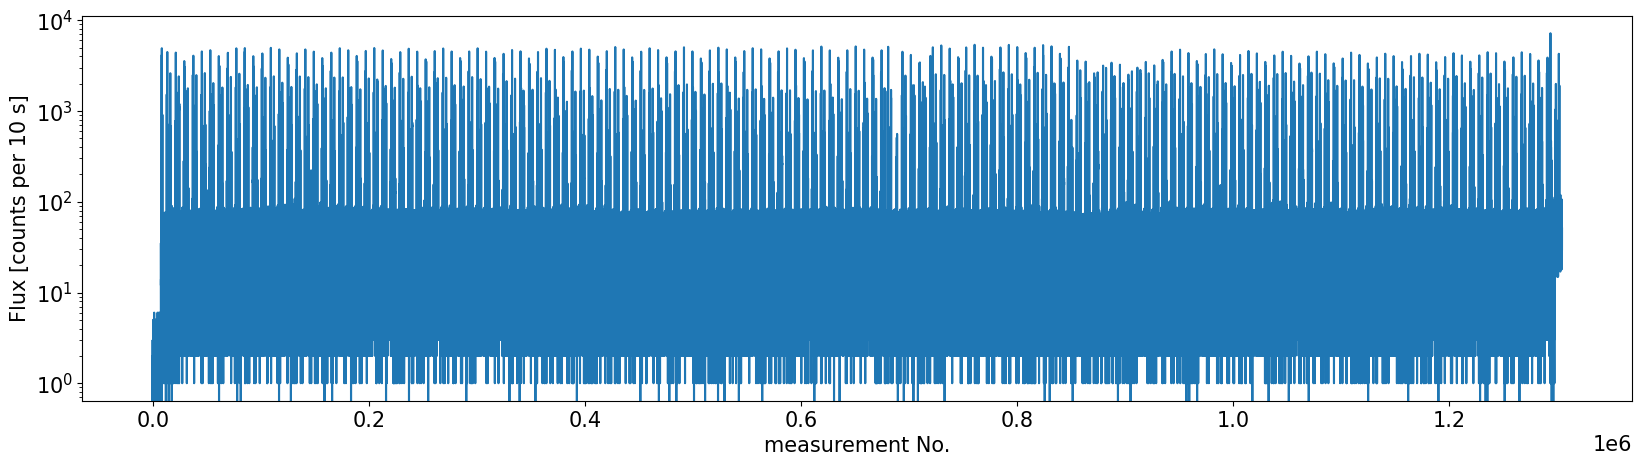

In [4]:
rc = rc.apply(pd.to_numeric, errors='coerce')

rc['sum'] = rc.iloc[:,10:28].sum(axis=1)

plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

rc['sum'].plot()
plt.yscale('log')

plt.xlabel('measurement No.')
plt.ylabel('Flux [counts per 10 s]')


In [5]:
# Monotone time

# ensure numbers
rc['2'] = pd.to_numeric(rc['2'], errors='coerce')

s = rc['2']

PAD = 5000  # kolik sekund přidat po každém resetu

# rozdíly mezi sousedními vzorky
d = s.diff()

# True tam, kde čas klesl (reset)
reset = d < 0

# o kolik se má offset zvýšit při resetu: předchozí hodnota + PAD
inc = np.where(reset, s.shift(1).fillna(0) + PAD, 0)

# kumulativní offset přes všechny resety
offset = pd.Series(inc, index=s.index).cumsum()

# nový monotónně rostoucí čas s mezerou PAD po každém resetu
rc['time'] = s + offset



In [22]:
import numpy as np
import pandas as pd

# ensure numbers 10..29
cols = [str(i) for i in range(9, 27)]
rc[cols] = rc[cols].apply(pd.to_numeric, errors='coerce')

# energy in keV: 152 keV for '6', +38 keV every next column
energies_keV = 152 + 38 * np.arange(len(cols))
energies_keV[-3] = 1000
energies_keV[-2] = 3000
energies_keV[-1] = 6000

# weighted sum
rc['ener'] = rc[cols].multiply(energies_keV, axis=1).sum(axis=1)


In [23]:
energies_keV


array([ 152,  190,  228,  266,  304,  342,  380,  418,  456,  494,  532,
        570,  608,  646,  684, 1000, 3000, 6000])

In [8]:
import numpy as np
import pandas as pd

# ensure numbers
rc['ener'] = pd.to_numeric(rc['ener'], errors='coerce')

# --- physical constants ---
keV_to_J = 1.602176634e-16          # [J/keV]
rho_Si_g_cm3 = 2.33                  # [g/cm^3]
# [mm] -> [mm^3] -> [cm^3]
vol_mm3 = 10 * 20 * 0.25             # = 50 mm^3
vol_cm3 = vol_mm3 / 1000.0           # = 0.05 cm^3
mass_kg = (vol_cm3 * rho_Si_g_cm3) / 1000.0   # 0.05*2.33 g -> kg

window_s = 10.0                      # integration window
# (J/keV) / kg * (3600/10) hod^-1 * 1e6 -> μGy/h / 1 keV
scale_uGy_per_h_per_keV = keV_to_J / mass_kg * (3600.0 / window_s) * 1e6

# ddsi in μGy/h
rc['ddsi'] = rc['ener'] * scale_uGy_per_h_per_keV


In [9]:
rc['time'] = pd.to_numeric(rc['time'], errors='coerce')

# launch time
ref_seconds = 7_587_246.0
ref_abs = pd.Timestamp('2020-10-14 05:45:04', tz='UTC')

t0 = ref_abs - pd.to_timedelta(ref_seconds, unit='s')

# time error (multiplicative drift)
k = 1.00002  # <-- koeficient škálování času

# constant time shift (in seconds)
t_shift = 0.0   # <-- sem dosaď svůj offset v sekundách (kladný = posun dopředu)

# calculation of absolute time
rc['abs_time'] = (
    ref_abs
    + pd.to_timedelta((rc['time'] - ref_seconds) * k, unit='s')
    + pd.to_timedelta(t_shift, unit='s')
)


## Orbital data

In [10]:
# Copy orbital data from ISS-coords-SPACEDOS-2020.tsv to temporary file
file_id = "1I-Pot6Nzn2XG22y4vRXj2TN343FdlIiW" # 2020
gdown.download(f"https://drive.google.com/uc?id={file_id}", "orbit.csv", quiet=True)

'orbit.csv'

In [11]:
# Read temporary file
cols = ['UTC', 'B', 'L']
orbit = pd.read_csv("orbit.csv", sep='\t', header=0, usecols=cols)

orbit.reset_index(drop=True, inplace=True)
orbit["UTC"] = pd.to_datetime(orbit["UTC"], unit="s", utc=True)

orbit.head()

,UTC,B,L
0,2020-10-14 05:45:04+00:00,43328.0,1.78487
1,2020-10-14 05:45:05+00:00,43346.9,1.78661
2,2020-10-14 05:45:06+00:00,43365.8,1.78835
3,2020-10-14 05:45:07+00:00,43384.7,1.79008
4,2020-10-14 05:45:08+00:00,43403.5,1.79182


Text(0, 0.5, '$\\.D$$_S$$_i$ [$\\mu$Gy/h]')

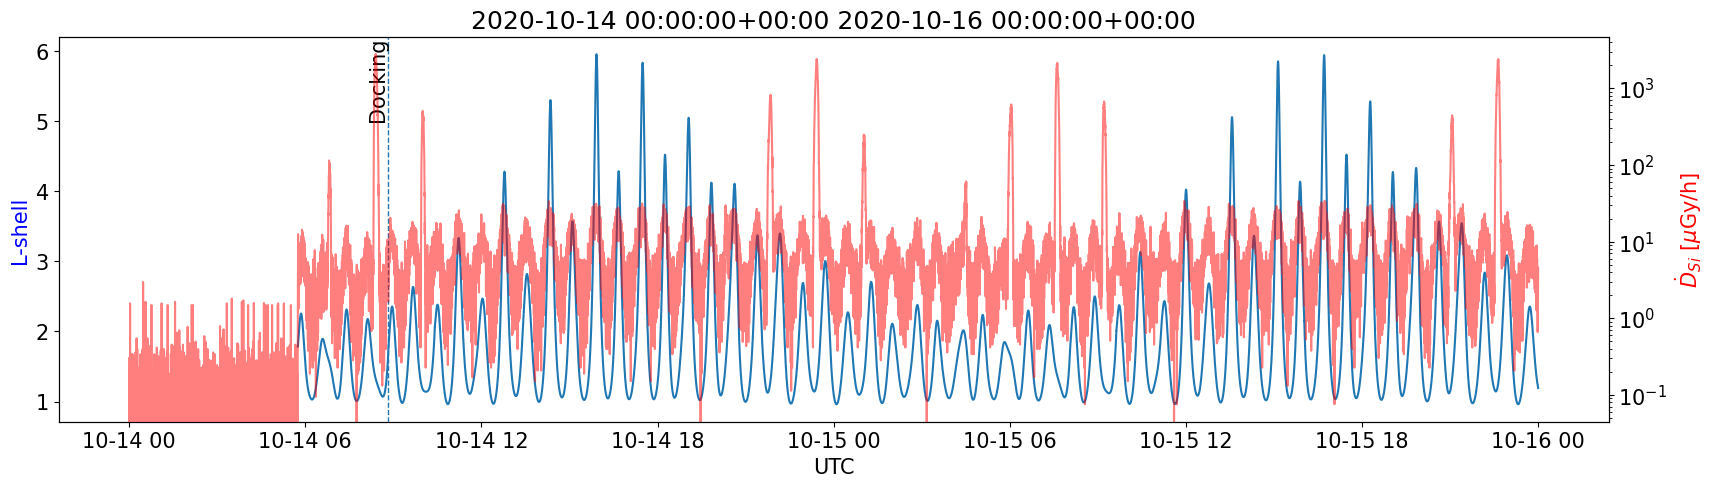

In [12]:
# --- zoom
tmin = pd.Timestamp("2020-10-14 00:00:00", tz="UTC")

tmax = tmin + pd.Timedelta(days=2)
zoom = orbit.loc[orbit["UTC"] < tmax].loc[orbit["UTC"] > tmin]


plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

ax1 = plt.gca()
ax1.plot(zoom["UTC"], zoom["L"], label="L")
ax1.set_xlabel("UTC")
ax1.set_ylabel("L-shell", color='blue')
ax1.set_title(str(tmin)+" "+str(tmax))

# --- Docking time ---
mark_t = pd.Timestamp("2020-10-14 08:48:47", tz="UTC")
ax1.axvline(mark_t, linestyle="--", linewidth=1)
ax1.text(mark_t, ax1.get_ylim()[1], "Docking",
         rotation=90, va="top", ha="right")

ax2 = ax1.twinx()

ax2.set_yscale('log')
#ax2.set_ylim(1,500)

zoom_data = rc.loc[rc["abs_time"] < tmax].loc[rc["abs_time"] > tmin]
ax2.plot(zoom_data["abs_time"], zoom_data["ddsi"], label="ddsi", color='red', alpha=0.5)
ax2.set_ylabel(r'$\.D$$_S$$_i$ [$\mu$Gy/h]', color='red')



## Time drift Correction

In [13]:

# 3) spočítat korigovaný čas
rc["corr_time"] = rc["abs_time"]


Text(0, 0.5, '$\\.D$$_S$$_i$ [$\\mu$Gy/h]')

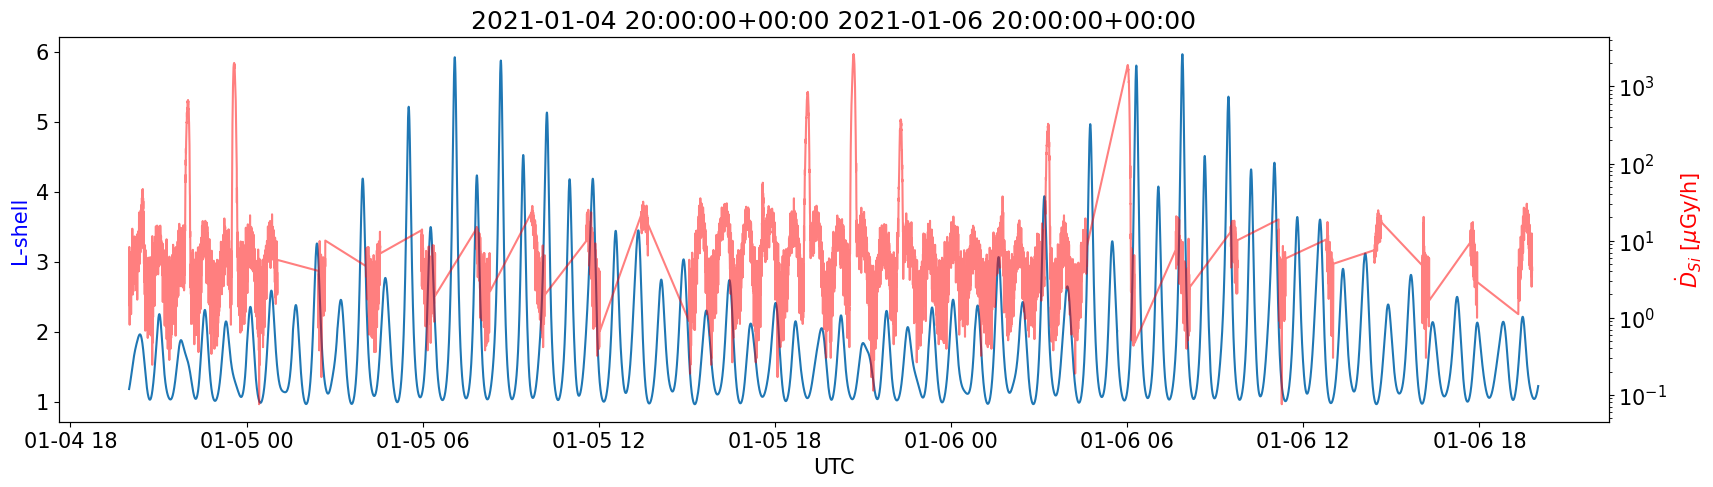

In [28]:
# --- zoom
tmin = pd.Timestamp("2020-10-14 00:00:00", tz="UTC") # Launch
tmin = pd.Timestamp("2020-12-14 00:00:00", tz="UTC")
tmin = pd.Timestamp("2021-01-04 20:00:00", tz="UTC") # 1st power break
tmax = tmin + pd.Timedelta(days=2)
zoom = orbit.loc[orbit["UTC"] < tmax].loc[orbit["UTC"] > tmin]


plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

ax1 = plt.gca()
ax1.plot(zoom["UTC"], zoom["L"], label="L")
ax1.set_xlabel("UTC")
ax1.set_ylabel("L-shell", color='blue')
ax1.set_title(str(tmin)+" "+str(tmax))

# --- Docking time
mark_t = pd.Timestamp("2019-09-25 19:42:40", tz="UTC")
#ax1.axvline(mark_t, linestyle="--", linewidth=1)
#ax1.text(mark_t, ax1.get_ylim()[1], "Docking",
#         rotation=90, va="top", ha="right")

ax2 = ax1.twinx()

ax2.set_yscale('log')
#ax2.set_ylim(1,500)

zoom_data = rc.loc[rc["corr_time"] < tmax].loc[rc["corr_time"] > tmin]
ax2.plot(zoom_data["corr_time"], zoom_data["ddsi"], label="ddsi", color='red', alpha=0.5)
ax2.set_ylabel(r'$\.D$$_S$$_i$ [$\mu$Gy/h]', color='red')



## Save output to file

In [15]:
ble
output_file = "SPACEDOS_ISS2020_corrected.csv"
rc.to_csv(output_file, index=False)

NameError: name 'ble' is not defined

In [ ]:
rc.iloc[600000]

## Spectrum

In [ ]:
rc

0.105 0.038


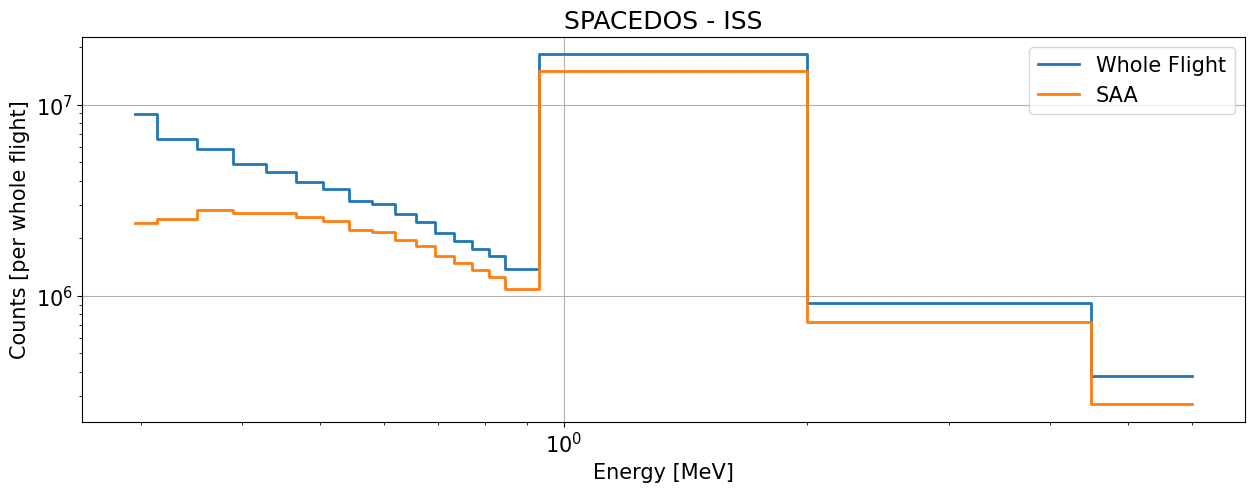

In [19]:
plt.figure(figsize=(15,5))
matplotlib.rcParams.update({'font.size': 15})

LOW_ENERGY = 10
HIGH_ENERGY = 29
CH = 4

ener1 = rc.iloc[:,LOW_ENERGY:HIGH_ENERGY].sum()
ener2 = rc.loc[(rc['sum']>80)].iloc[:,LOW_ENERGY:HIGH_ENERGY].sum() # SAA

coef = np.array([0.,0.])
coef[1] = 0.038
coef[0] = 0.105

print (coef[0], coef[1])

e = pd.DataFrame()
e['1'] = ener1
e['i'] = ener1.index
e['x'] = (e['i'].astype(float)-CH) * coef[1] + coef[0]
e.iloc[16,2] = 1
e.iloc[17,2] = 3
e.iloc[18,2] = 6

plt.yscale('log')
plt.xscale('log')

plt.plot(e['x'], e['1'], label='Whole Flight', lw=2, drawstyle='steps-mid')

e['1'] = ener2
e['i'] = ener2.index
plt.plot(e['x'], e['1'], label='SAA', lw=2, drawstyle='steps-mid')

plt.legend()
plt.title('SPACEDOS - ISS')
plt.xlabel('Energy [MeV]')
plt.ylabel(r'Counts [per whole flight]')
plt.grid()

In [21]:
e

,1,i,x
9,2391341.0,9,0.295
10,2509705.0,10,0.333
11,2800466.0,11,0.371
12,2720594.0,12,0.409
13,2698339.0,13,0.447
14,2572766.0,14,0.485
15,2470596.0,15,0.523
16,2194497.0,16,0.561
17,2162736.0,17,0.599
18,1958047.0,18,0.637


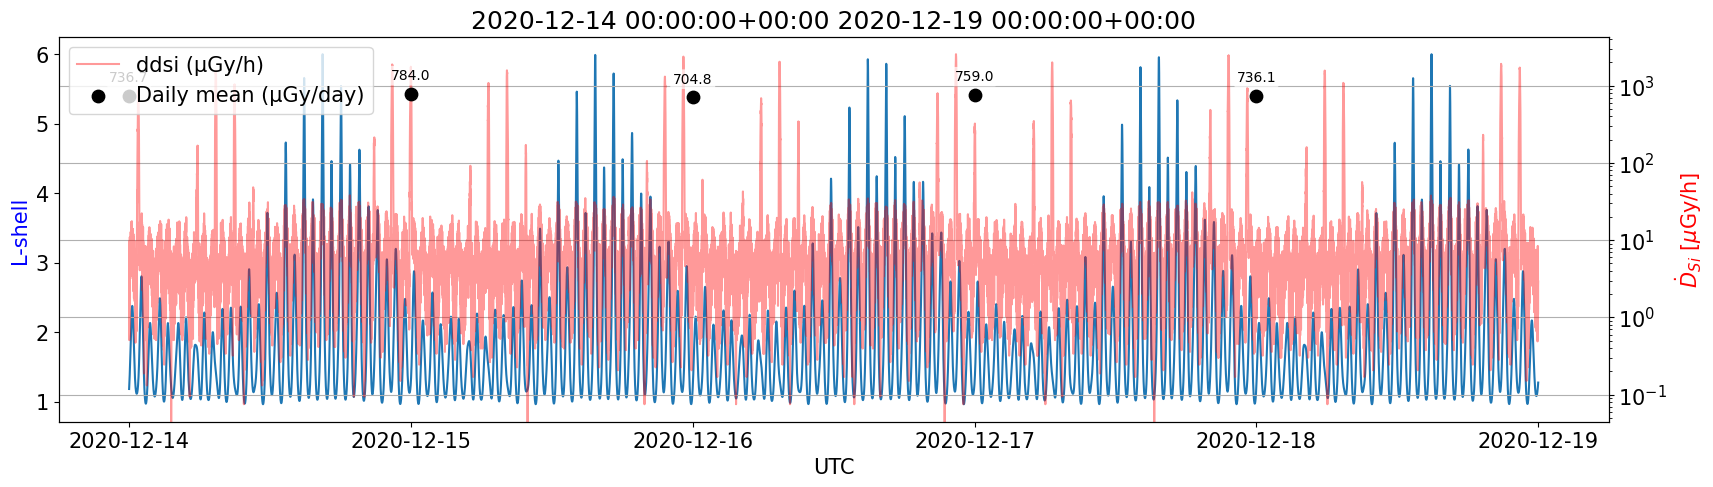

In [20]:
# --- zoom
tmin = pd.Timestamp("2020-10-14 00:00:00", tz="UTC") # Launch
tmin = pd.Timestamp("2020-12-14 00:00:00", tz="UTC")
#tmin = pd.Timestamp("2021-01-04 00:00:00", tz="UTC")
tmax = tmin + pd.Timedelta(days=5)
zoom = orbit.loc[(orbit["UTC"] > tmin) & (orbit["UTC"] < tmax)]

plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

ax1 = plt.gca()
ax1.plot(zoom["UTC"], zoom["L"], label="L")
ax1.set_xlabel("UTC")
ax1.set_ylabel("L-shell", color='blue')
ax1.set_title(str(tmin)+" "+str(tmax))

# --- Docking time
mark_t = pd.Timestamp("2019-09-25 19:42:40", tz="UTC")

ax2 = ax1.twinx()
ax2.set_yscale('log')

zoom_data = rc.loc[(rc["corr_time"] > tmin) & (rc["corr_time"] < tmax)]

# původní průběžná data
ax2.plot(zoom_data["corr_time"], zoom_data["ddsi"],
         label="ddsi (µGy/h)", color='red', alpha=0.4)

ax2.set_ylabel(r'$\.D$$_S$$_i$ [$\mu$Gy/h]', color='red')

# --- denní průměry v µGy/day
daily = zoom_data.set_index("corr_time")["ddsi"].resample("D").mean() * 24.0
ax2.scatter(daily.index, daily, color='black', s=80, zorder=5, label="Daily mean (µGy/day)", marker='o')
ax2.grid()

ax2.legend(loc='upper left')

# popisky hodnot u denních průměrů
daily_clean = daily.dropna()
for x, y in zip(daily_clean.index, daily_clean.values):
    ax2.annotate(f"{y:.1f}", (x, y),
                 textcoords="offset points", xytext=(0, 8),
                 ha="center", va="bottom",
                 fontsize=10, color="black",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))



Text(0, 0.5, '$\\.D$$_S$$_i$ [$\\mu$Gy/h]')

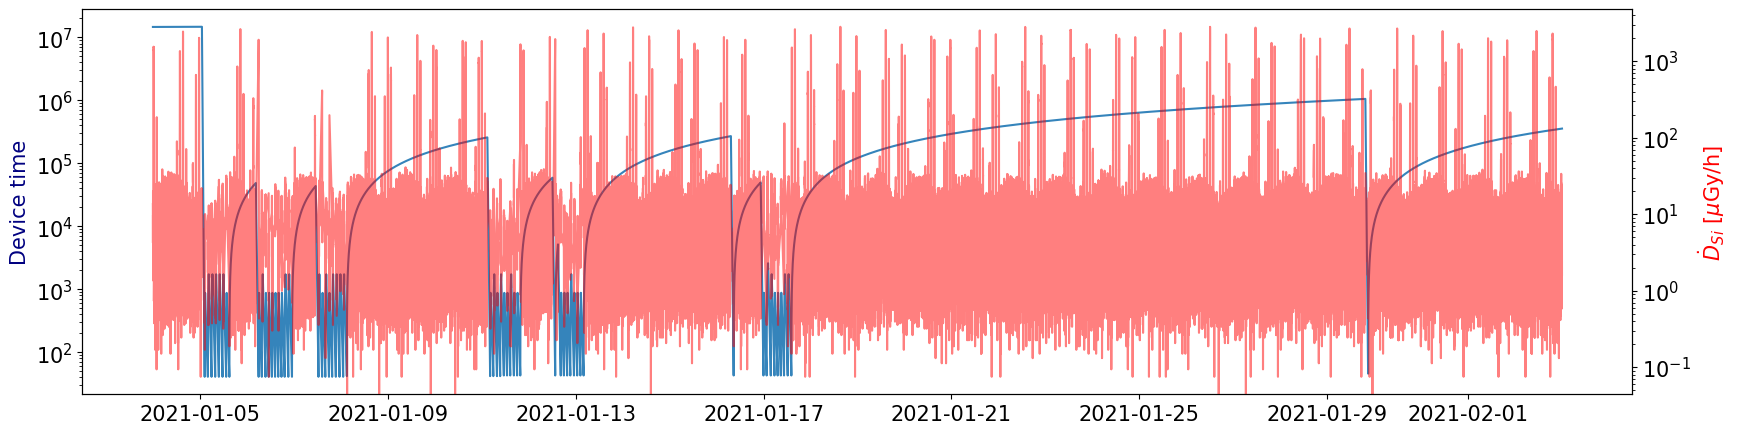

In [45]:
# --- zoom
tmin = pd.Timestamp("2020-10-14 00:00:00", tz="UTC") # Launch
tmin = pd.Timestamp("2020-12-14 00:00:00", tz="UTC")
tmin = pd.Timestamp("2021-01-04 00:00:00", tz="UTC") # 1st power interrupt
tmax = tmin + pd.Timedelta(days=30)
zoom = orbit.loc[orbit["UTC"] < tmax].loc[orbit["UTC"] > tmin]


plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

ax1 = plt.gca()

zoom_data = rc.loc[rc["corr_time"] < tmax].loc[rc["corr_time"] > tmin]
ax1.plot(zoom_data["corr_time"], zoom_data['2'], label="Device time", alpha=0.9)
ax1.set_ylabel(r'Device time', color='navy')
ax1.set_yscale('log')

ax2 = ax1.twinx()

ax2.set_yscale('log')
#ax2.set_ylim(1,500)

zoom_data = rc.loc[rc["corr_time"] < tmax].loc[rc["corr_time"] > tmin]
ax2.plot(zoom_data["corr_time"], zoom_data["ddsi"], label="ddsi", color='red', alpha=0.5)
ax2.set_ylabel(r'$\.D$$_S$$_i$ [$\mu$Gy/h]', color='red')



In [30]:
rc

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,24,25,26,27,sum,time,ener,ddsi,abs_time,corr_time
0,3,NaN,0,7509128.0,24782,259,0.0,13171.0,8008.0,38.0,...,0.0,0.0,0.0,0.0,1.0,7509128.0,228.0,0.112881,2020-10-13 08:03:04.437640+00:00,2020-10-13 08:03:04.437640+00:00
1,4,NaN,1,7509139.0,24741,260,0.0,13478.0,7742.0,37.0,...,0.0,0.0,0.0,0.0,2.0,7509139.0,608.0,0.301017,2020-10-13 08:03:15.437860+00:00,2020-10-13 08:03:15.437860+00:00
2,5,NaN,2,7509149.0,24606,259,1.0,14414.0,6954.0,24.0,...,0.0,0.0,0.0,0.0,1.0,7509149.0,152.0,0.075254,2020-10-13 08:03:25.438060+00:00,2020-10-13 08:03:25.438060+00:00
3,6,NaN,3,7509160.0,24685,259,0.0,13871.0,7408.0,35.0,...,0.0,0.0,0.0,0.0,1.0,7509160.0,304.0,0.150508,2020-10-13 08:03:36.438280+00:00,2020-10-13 08:03:36.438280+00:00
4,7,NaN,4,7509170.0,24585,260,3.0,14294.0,7088.0,29.0,...,0.0,0.0,0.0,0.0,1.0,7509170.0,190.0,0.094068,2020-10-13 08:03:46.438480+00:00,2020-10-13 08:03:46.438480+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304795,1305081,NaN,60619,4875058.0,24444,259,13.0,16230.0,5199.0,62.0,...,0.0,2.0,0.0,0.0,52.0,21761517.0,16412.0,8.125470,2021-03-27 07:07:38.485419998+00:00,2021-03-27 07:07:38.485419998+00:00
1304796,1305082,NaN,60620,4875069.0,24440,259,16.0,16042.0,5385.0,75.0,...,0.0,0.0,1.0,0.0,42.0,21761528.0,14816.0,7.335301,2021-03-27 07:07:49.485639999+00:00,2021-03-27 07:07:49.485639999+00:00
1304797,1305083,NaN,60621,4875079.0,24460,259,4.0,16030.0,5401.0,61.0,...,0.0,0.0,1.0,0.0,44.0,21761538.0,14550.0,7.203606,2021-03-27 07:07:59.485839998+00:00,2021-03-27 07:07:59.485839998+00:00
1304798,1305084,NaN,60622,4875090.0,24402,259,11.0,16327.0,5160.0,66.0,...,0.0,0.0,0.0,0.0,34.0,21761549.0,8550.0,4.233047,2021-03-27 07:08:10.486059999+00:00,2021-03-27 07:08:10.486059999+00:00
